In [1]:
import tensorflow as tf
from tensorflow import keras

import matplotlib.pyplot as plt

In [2]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Print shapes to verify
print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Test labels shape: {y_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


In [3]:
print(f"Image size: {x_train.shape[1:3]}")  # (32, 32)
print(f"Number of channels: {x_train.shape[3]}")  # 3

# Define image_shape for later use
image_shape = x_train.shape[1:]

Image size: (32, 32)
Number of channels: 3


In [4]:
print(image_shape)

(32, 32, 3)


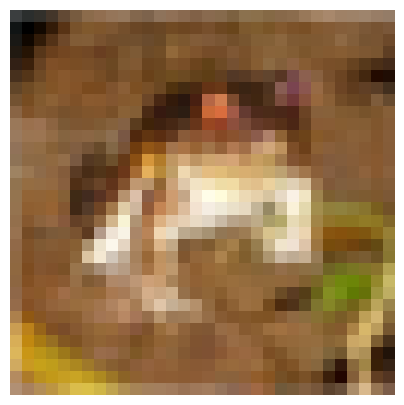

In [5]:
# Mostrar la imagen con mejor resolución
plt.figure(figsize=(5, 5))  # Aumentar el tamaño de la figura para mejor visualización
plt.imshow(x_train[0])  # Mostrar la primera imagen del conjunto de entrenamiento
plt.axis('off')  # Desactivar los ejes
plt.show()

In [6]:
x_train[0]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

In [7]:
# Normalize the pixel values to the range [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

In [8]:
x_train[0]

array([[[0.23137255, 0.24313725, 0.24705882],
        [0.16862745, 0.18039216, 0.17647059],
        [0.19607843, 0.18823529, 0.16862745],
        ...,
        [0.61960784, 0.51764706, 0.42352941],
        [0.59607843, 0.49019608, 0.4       ],
        [0.58039216, 0.48627451, 0.40392157]],

       [[0.0627451 , 0.07843137, 0.07843137],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509804, 0.21568627],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117647, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215686, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941176, 0.19607843],
        [0.47058824, 0.32941176, 0.19607843],
        [0.42745098, 0.28627451, 0.16470588]],

       ...,

       [[0.81568627, 0.66666667, 0.37647059],
        [0.78823529, 0.6       , 0.13333333],
        [0.77647059, 0

In [9]:
nombre_clases=['avión', 'automóvil', 'pájaro', 'gato', 'ciervo', 'perro', 'rana', 'caballo', 'barco', 'camión']

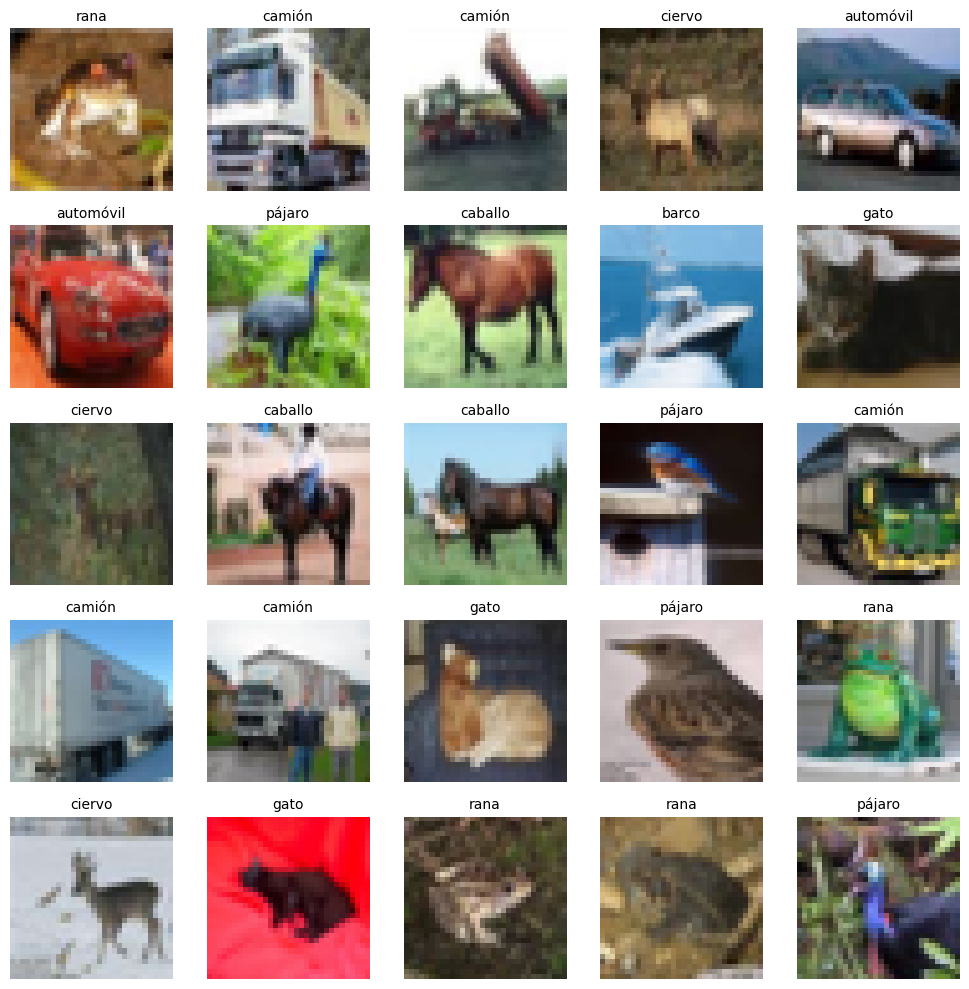

In [10]:
import matplotlib.pyplot as plt

# Create a figure with 5x5 subplots
fig, axes = plt.subplots(5, 5, figsize=(10, 10))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Display the first 25 images with their class names
for i in range(25):
    axes[i].imshow(x_train[i])
    axes[i].set_title(nombre_clases[y_train[i][0]], fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [11]:
from tensorflow.keras import layers

modelo = tf.keras.Sequential([
	layers.Input(shape=image_shape),
	layers.Conv2D(32, (3, 3), activation='relu'),
	layers.MaxPooling2D((2, 2)),
	layers.Conv2D(64, (3, 3), activation='relu'),
	layers.MaxPooling2D((2, 2))
])

In [12]:
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
modelo = tf.keras.Sequential([
    layers.Input(shape=image_shape),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [14]:
modelo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169,322 (661.41 KB)

 Trainable params: 169,322 (661.41 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
modelo.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

history = modelo.fit(x_train, y_train, epochs=15,
                     validation_data=(x_test, y_test))


Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.3496 - loss: 1.7506 - val_accuracy: 0.5464 - val_loss: 1.2575
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5864 - loss: 1.1737 - val_accuracy: 0.6298 - val_loss: 1.0619
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6440 - loss: 1.0120 - val_accuracy: 0.6610 - val_loss: 0.9775
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6824 - loss: 0.9102 - val_accuracy: 0.6705 - val_loss: 0.9545
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7022 - loss: 0.8468 - val_accuracy: 0.6836 - val_loss: 0.9108
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7272 - loss: 0.7793 - val_accuracy: 0.6757 - val_loss: 0.9417
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7455 - loss: 0.7232 - val_accuracy: 0.6911 - val_loss: 0.9087
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7620 - loss: 0.6837 -

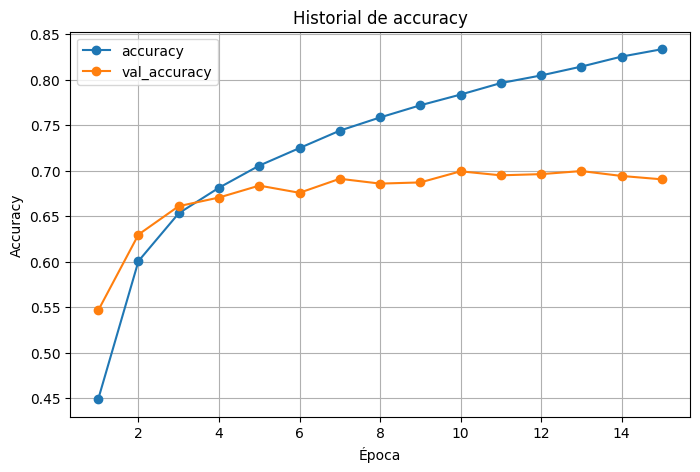

In [16]:
acc = history.history['accuracy']
val_acc = history.history.get('val_accuracy')
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, acc, label='accuracy', marker='o')
if val_acc is not None:
    plt.plot(epochs, val_acc, label='val_accuracy', marker='o')

plt.title('Historial de accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Status code: 200
Content-Type: image/jpeg
Tamaño: 490372 bytes
Primeros bytes: b'\xff\xd8\xff\xdb\x00C\x00\x04\x03\x03\x04\x03\x03\x04\x04\x03\x04\x05\x04\x04'


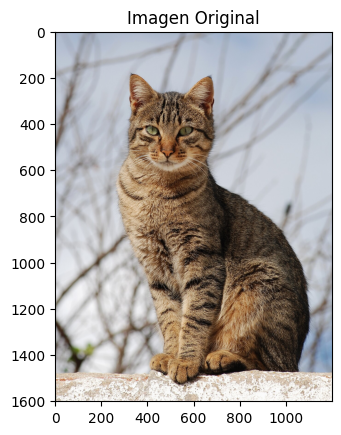

In [22]:
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

url = "https://upload.wikimedia.org/wikipedia/commons/thumb/4/4d/Cat_November_2010-1a.jpg/1200px-Cat_November_2010-1a.jpg"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}

response = requests.get(url, headers=headers, timeout=10)

print(f"Status code: {response.status_code}")
print(f"Content-Type: {response.headers.get('Content-Type')}")
print(f"Tamaño: {len(response.content)} bytes")
print(f"Primeros bytes: {response.content[:20]}")  # los primeros bytes revelan el tipo de archivo

# Solo abre si es imagen
if response.status_code == 200 and "image" in response.headers.get("Content-Type", ""):
    img = Image.open(BytesIO(response.content))
    plt.imshow(img)
    plt.title('Imagen Original')
    plt.axis('on')
    plt.show()
else:
    print("No se recibió una imagen válida")
    print("Respuesta del servidor:", response.text[:500])

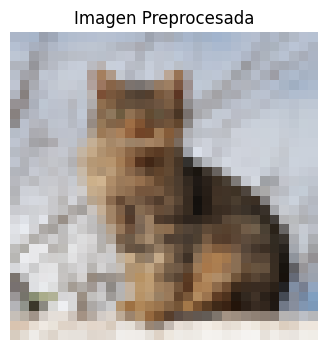

In [27]:
import numpy as np
from tensorflow.keras.preprocessing.image import img_to_array

# Redimensionar la imagen a (32, 32) para que coincida con el modelo
img_resized = img.resize((32, 32))

# Convertir la imagen redimensionada a un arreglo NumPy
img_array = img_to_array(img_resized)

# Normalizar la imagen (dividir entre 255)
img_array = img_array / 255.0

# Añadir una dimensión extra para que la imagen tenga el formato correcto (batch size, height, width, channels)
img_array = np.expand_dims(img_array, axis=0)

# Mostrar la imagen preprocesada
plt.figure(figsize=(4, 4))
plt.imshow(img_array[0])
plt.title('Imagen Preprocesada')
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 800ms/step


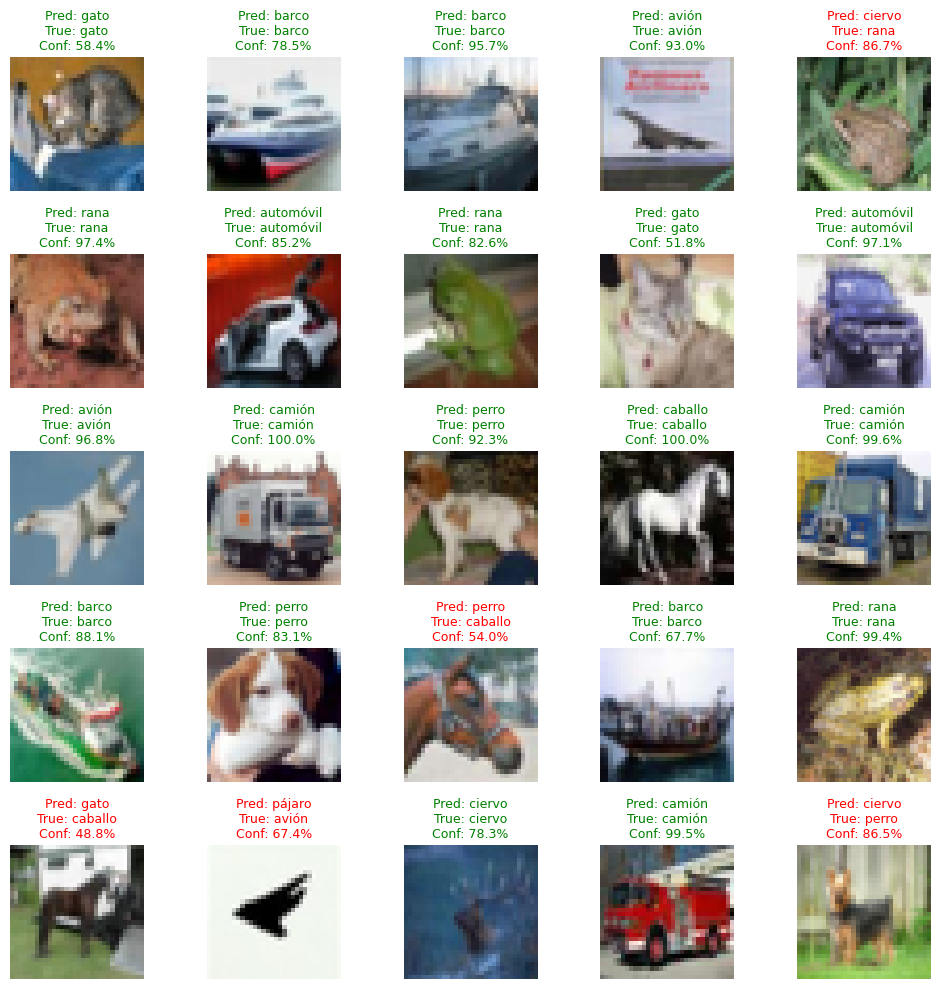

In [28]:
# Get predictions for the first 25 test images
predictions = modelo.predict(x_test[:25])

# Create a figure with 5x5 subplots
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
axes = axes.flatten()

# Display the first 25 test images with their predictions and true labels
for i in range(25):
    axes[i].imshow(x_test[i])
    predicted_class = np.argmax(predictions[i])
    true_class = y_test[i][0]
    
    predicted_label = nombre_clases[predicted_class]
    true_label = nombre_clases[true_class]
    confidence = predictions[i][predicted_class] * 100
    
    # Color title green if correct, red if incorrect
    color = 'green' if predicted_class == true_class else 'red'
    axes[i].set_title(f"Pred: {predicted_label}\nTrue: {true_label}\nConf: {confidence:.1f}%", 
                     fontsize=9, color=color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [29]:
from google.colab import drive

drive.mount('/content/drive')

ruta_modelo = '/content/drive/MyDrive/modelo_convolucionales.keras'
modelo.save(ruta_modelo)

print(f'Modelo guardado en: {ruta_modelo}')

Mounted at /content/drive
Modelo guardado en: /content/drive/MyDrive/modelo_convolucionales.keras
